In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

X_train = train_df["Line"]
y_train = train_df["label"]
X_test = test_df["Line"]
y_test = test_df["label"]

label_names = ['Butters', 'Cartman', 'Kyle', 'Mr. Garrison', 'Randy', 'Stan']

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 20544
Test size: 5137


In [17]:
def evaluate_model(model, vectorizer, X_test, y_test, label_names, model_name):
    X_test_vec = vectorizer.transform(X_test)
    y_pred = model.predict(X_test_vec)
    
    print(f"=== {model_name} ===")
    print(classification_report(y_test, y_pred, target_names=label_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.savefig(f"../outputs/cm_{model_name.replace(' ', '_')}.png")
    plt.show()
    
    return y_pred

=== TF-IDF Unigrams ===
              precision    recall  f1-score   support

     Butters       0.34      0.51      0.41       422
     Cartman       0.62      0.50      0.55      1697
        Kyle       0.41      0.32      0.36      1153
Mr. Garrison       0.24      0.48      0.32       183
       Randy       0.32      0.53      0.40       432
        Stan       0.44      0.40      0.42      1250

    accuracy                           0.44      5137
   macro avg       0.39      0.46      0.41      5137
weighted avg       0.47      0.44      0.44      5137



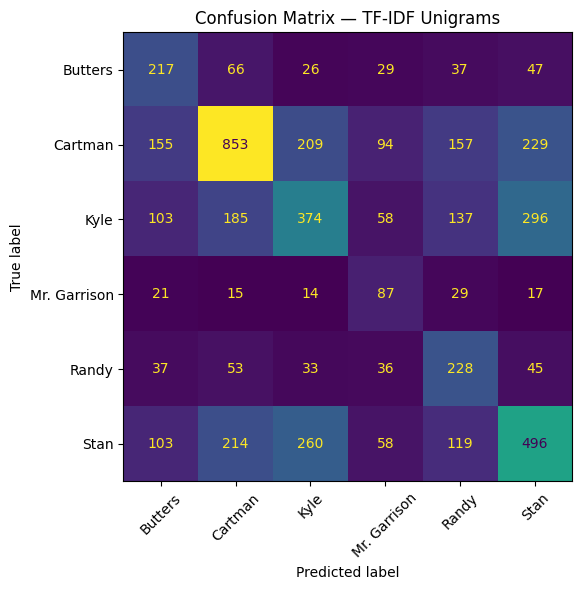

In [18]:
vectorizer_tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,1))
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)

model_tfidf = LogisticRegression(max_iter=1000, class_weight="balanced")
model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = evaluate_model(model_tfidf, vectorizer_tfidf, X_test, y_test, label_names, "TF-IDF Unigrams")

=== Word Bigrams ===
              precision    recall  f1-score   support

     Butters       0.38      0.51      0.44       422
     Cartman       0.59      0.56      0.58      1697
        Kyle       0.41      0.34      0.37      1153
Mr. Garrison       0.30      0.40      0.35       183
       Randy       0.35      0.49      0.41       432
        Stan       0.45      0.41      0.43      1250

    accuracy                           0.46      5137
   macro avg       0.41      0.45      0.43      5137
weighted avg       0.47      0.46      0.46      5137



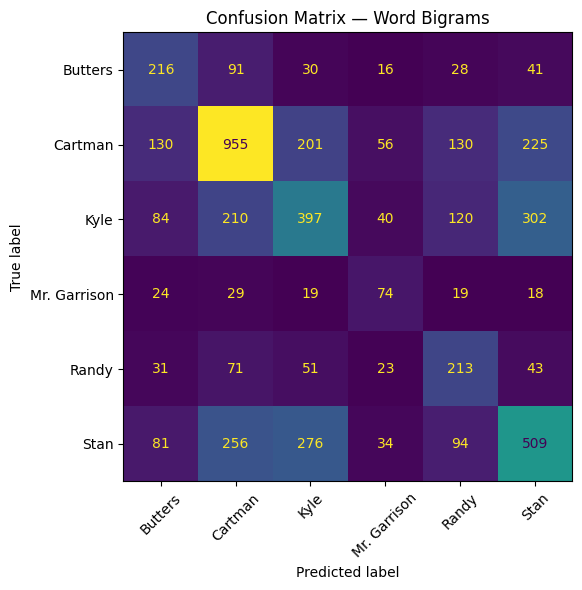

In [19]:
vectorizer_word_bigram = TfidfVectorizer(analyzer="word", ngram_range=(1,2))
X_train_word_bigram = vectorizer_word_bigram.fit_transform(X_train)

model_word_bigram = LogisticRegression(max_iter=1000, class_weight="balanced")
model_word_bigram.fit(X_train_word_bigram, y_train)

pred_word_bigram = evaluate_model(model_word_bigram, vectorizer_word_bigram, X_test, y_test, label_names, "Word Bigrams")


=== Character N-grams ===
              precision    recall  f1-score   support

     Butters       0.38      0.56      0.45       422
     Cartman       0.63      0.52      0.57      1697
        Kyle       0.43      0.35      0.39      1153
Mr. Garrison       0.24      0.47      0.32       183
       Randy       0.32      0.52      0.40       432
        Stan       0.44      0.40      0.42      1250

    accuracy                           0.45      5137
   macro avg       0.41      0.47      0.42      5137
weighted avg       0.48      0.45      0.46      5137



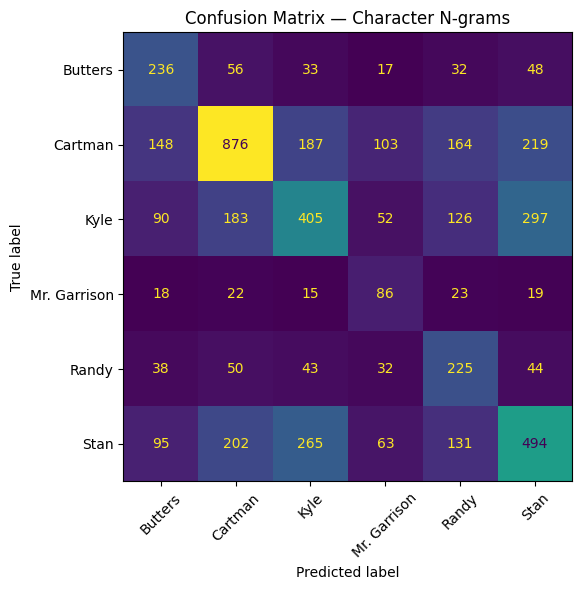

In [20]:
vectorizer_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))
X_train_char = vectorizer_char.fit_transform(X_train)

model_char = LogisticRegression(max_iter=1000, class_weight="balanced")
model_char.fit(X_train_char, y_train)

pred_char = evaluate_model(model_char, vectorizer_char, X_test, y_test, label_names, "Character N-grams")

In [21]:
results = {
    "Model": ["TF-IDF Unigrams", "Word Bigrams", "Character N-grams"],
    "Accuracy": [0.44, 0.46, 0.45],
    "Macro F1": [0.41, 0.43, 0.42]
}

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

            Model  Accuracy  Macro F1
  TF-IDF Unigrams      0.44      0.41
     Word Bigrams      0.46      0.43
Character N-grams      0.45      0.42


## DistilBERT

In [22]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Check if GPU is available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [23]:
class SouthParkDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [24]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_dataset = SouthParkDataset(train_df["Line"], train_df["label"], tokenizer)
test_dataset = SouthParkDataset(test_df["Line"], test_df["label"], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 642
Test batches: 161


In [25]:
model_distilbert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)
model_distilbert = model_distilbert.to(device)

# Optimizer and scheduler
num_epochs = 3
optimizer = AdamW(model_distilbert.parameters(), lr=2e-5)
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print(f"Total training steps: {num_training_steps}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8833.09it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 1926


In [15]:
import time

for epoch in range(num_epochs):
    model_distilbert.train()
    total_loss = 0
    start = time.time()
    
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model_distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
    
    avg_loss = total_loss / len(train_loader)
    elapsed = round(time.time() - start, 1)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f} — Time: {elapsed}s")

print("Training done!")

Epoch 1/3 — Loss: 1.4136 — Time: 614.4s
Epoch 2/3 — Loss: 1.2169 — Time: 635.2s
Epoch 3/3 — Loss: 1.0897 — Time: 692.3s
Training done!


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6448.39it/s]


=== DistilBERT ===
              precision    recall  f1-score   support

     Butters       0.51      0.41      0.45       422
     Cartman       0.57      0.65      0.61      1697
        Kyle       0.42      0.39      0.40      1153
Mr. Garrison       0.63      0.26      0.37       183
       Randy       0.60      0.32      0.42       432
        Stan       0.42      0.50      0.46      1250

    accuracy                           0.49      5137
   macro avg       0.52      0.42      0.45      5137
weighted avg       0.50      0.49      0.49      5137



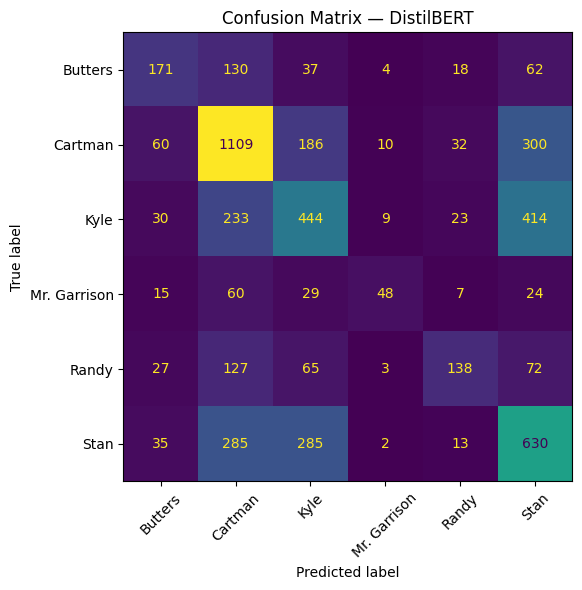

In [45]:
model_distilbert = DistilBertForSequenceClassification.from_pretrained("../models/distilbert")
model_distilbert = model_distilbert.to(device)
model_distilbert.eval()

all_preds_distilbert = []
all_labels_distilbert = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model_distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds_distilbert.extend(preds.cpu().numpy())
        all_labels_distilbert.extend(labels.cpu().numpy())

print("=== DistilBERT ===")
print(classification_report(all_labels_distilbert, all_preds_distilbert, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels_distilbert, all_preds_distilbert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — DistilBERT")
plt.tight_layout()
plt.savefig("../outputs/cm_distilbert.png")
plt.show()

In [18]:
model_distilbert.save_pretrained("../models/distilbert")
tokenizer.save_pretrained("../models/distilbert")
print("Model saved.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s]

Model saved.


## RoBERTa

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import DataLoader
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

tokenizer_roberta = RobertaTokenizer.from_pretrained("../models/roberta/epoch_3")

train_dataset_roberta = SouthParkDataset(train_df["Line"], train_df["label"], tokenizer_roberta)
test_dataset_roberta = SouthParkDataset(test_df["Line"], test_df["label"], tokenizer_roberta)

train_loader_roberta = DataLoader(train_dataset_roberta, batch_size=32, shuffle=True)
test_loader_roberta = DataLoader(test_dataset_roberta, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader_roberta)}")
print(f"Test batches: {len(test_loader_roberta)}")

Train batches: 642
Test batches: 161


In [32]:
model_roberta = RobertaForSequenceClassification.from_pretrained(
    "../models/roberta/epoch_3",
    num_labels=6
)
model_roberta = model_roberta.to(device)

# Optimizer and scheduler
num_epochs = 3
optimizer_roberta = AdamW(model_roberta.parameters(), lr=2e-5)
num_training_steps = num_epochs * len(train_loader_roberta)
lr_scheduler_roberta = get_scheduler(
    "linear",
    optimizer=optimizer_roberta,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print(f"Total training steps: {num_training_steps}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7401.13it/s]


Total training steps: 1926


In [25]:
import os

os.makedirs("../models/roberta", exist_ok=True)

for epoch in range(num_epochs):
    model_roberta.train()
    total_loss = 0
    start = time.time()
    
    for batch in train_loader_roberta:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        optimizer_roberta.step()
        lr_scheduler_roberta.step()
        optimizer_roberta.zero_grad()
    
    avg_loss = total_loss / len(train_loader_roberta)
    elapsed = round(time.time() - start, 1)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f} — Time: {elapsed}s")
    
    # Save checkpoint after each epoch
    checkpoint_path = f"../models/roberta/epoch_{epoch+1}"
    model_roberta.save_pretrained(checkpoint_path)
    tokenizer_roberta.save_pretrained(checkpoint_path)
    print(f"Checkpoint saved to {checkpoint_path}")

print("Training done!")

Epoch 1/3 — Loss: 1.4182 — Time: 3875.0s


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.32s/it]


Checkpoint saved to ../models/roberta/epoch_1
Epoch 2/3 — Loss: 1.2206 — Time: 3063.2s


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.10s/it]


Checkpoint saved to ../models/roberta/epoch_2
Epoch 3/3 — Loss: 1.0936 — Time: 3057.1s


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.60s/it]

Checkpoint saved to ../models/roberta/epoch_3
Training done!


=== RoBERTa ===
              precision    recall  f1-score   support

     Butters       0.55      0.43      0.48       422
     Cartman       0.60      0.63      0.61      1697
        Kyle       0.45      0.32      0.38      1153
Mr. Garrison       0.61      0.25      0.36       183
       Randy       0.52      0.43      0.47       432
        Stan       0.41      0.58      0.48      1250

    accuracy                           0.50      5137
   macro avg       0.52      0.44      0.46      5137
weighted avg       0.51      0.50      0.50      5137



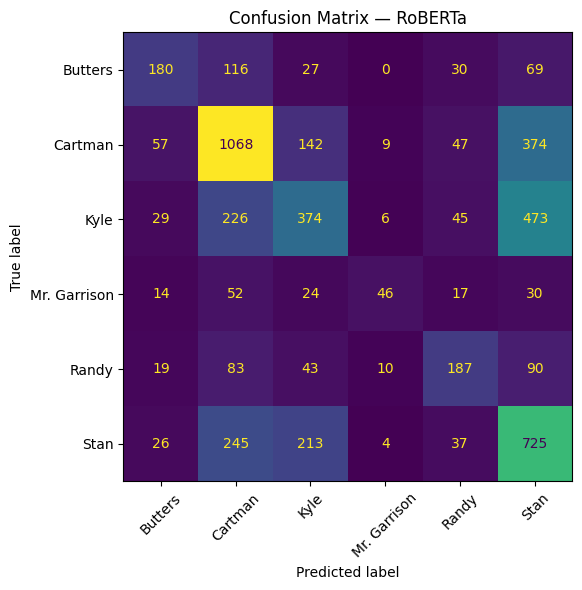

In [35]:
model_roberta.eval()
all_preds_roberta = []
all_labels_roberta = []

with torch.no_grad():
    for batch in test_loader_roberta:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds_roberta.extend(preds.cpu().numpy())
        all_labels_roberta.extend(labels.cpu().numpy())

print("=== RoBERTa ===")
print(classification_report(all_labels_roberta, all_preds_roberta, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels_roberta, all_preds_roberta)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — RoBERTa")
plt.tight_layout()
plt.savefig("../outputs/cm_roberta.png")
plt.show()

In [46]:
results = {
    "Model": ["TF-IDF Unigrams", "Word Uni+Bigrams", "Character N-grams", "DistilBERT", "RoBERTa"],
    "Accuracy": [0.44, 0.46, 0.45, 0.49, 0.50],
    "Macro F1": [0.41, 0.43, 0.42, 0.45, 0.46]
}

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

            Model  Accuracy  Macro F1
  TF-IDF Unigrams      0.44      0.41
 Word Uni+Bigrams      0.46      0.43
Character N-grams      0.45      0.42
       DistilBERT      0.49      0.45
          RoBERTa      0.50      0.46


## SHAP

In [47]:
import shap

vectorizer_shap = TfidfVectorizer(analyzer="word", ngram_range=(1,2))
X_train_shap = vectorizer_shap.fit_transform(X_train)
X_test_shap = vectorizer_shap.transform(X_test)

model_shap = LogisticRegression(max_iter=1000, class_weight="balanced")
model_shap.fit(X_train_shap, y_train)

print("Model trained, starting SHAP analysis...")

explainer = shap.LinearExplainer(model_shap, X_train_shap)
shap_values = explainer(X_test_shap[:500])

print("SHAP values computed!")

Model trained, starting SHAP analysis...
SHAP values computed!


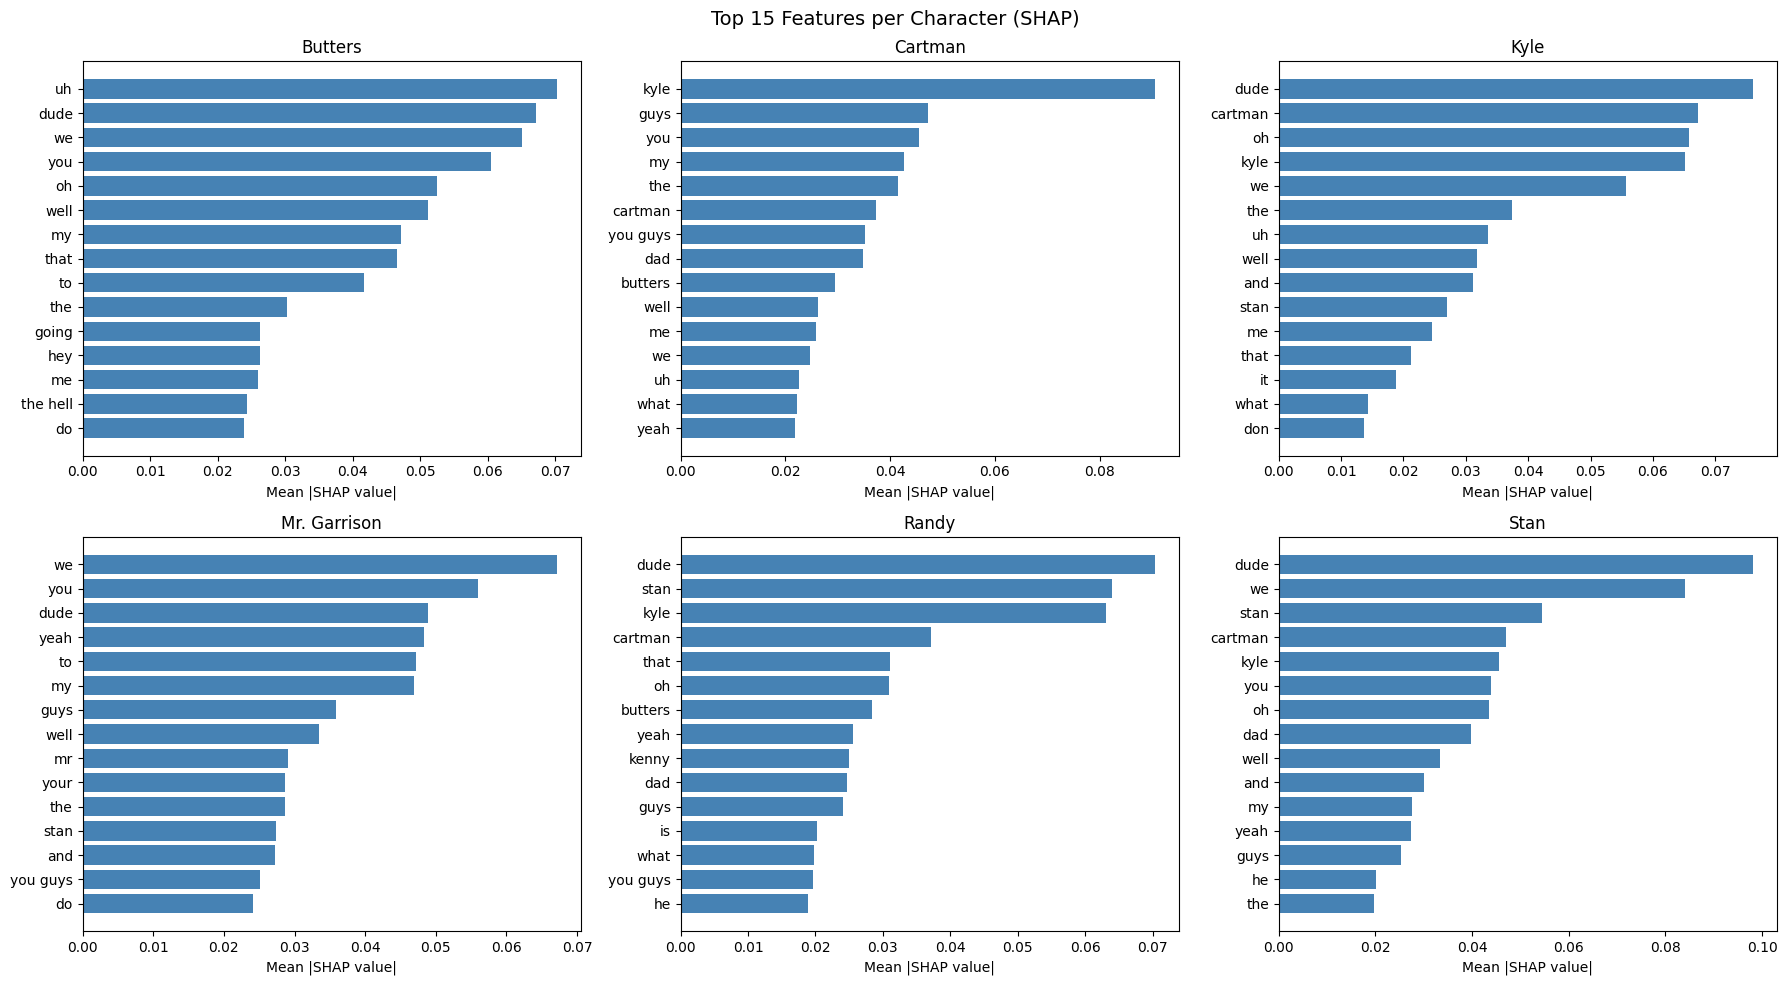

In [48]:
feature_names = vectorizer_shap.get_feature_names_out()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, character in enumerate(label_names):
    shap_vals = shap_values.values[:, :, i]
    mean_shap = abs(shap_vals).mean(axis=0)
    top_idx = mean_shap.argsort()[-15:][::-1]
    top_features = feature_names[top_idx]
    top_values = mean_shap[top_idx]
    
    axes[i].barh(top_features[::-1], top_values[::-1], color="steelblue")
    axes[i].set_title(f"{character}")
    axes[i].set_xlabel("Mean |SHAP value|")

plt.suptitle("Top 15 Features per Character (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/shap_features.png")
plt.show()

In [49]:
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["predicted"] = all_preds_roberta
test_df_copy["correct"] = test_df_copy["label"] == test_df_copy["predicted"]

# Map predicted labels to character names
test_df_copy["predicted_name"] = test_df_copy["predicted"].map(
    {i: name for i, name in enumerate(label_names)}
)

# Show misclassified lines
errors = test_df_copy[test_df_copy["correct"] == False]
print(f"Total misclassified: {len(errors)} / {len(test_df_copy)}")
print(f"\nSample misclassified lines:")
print(errors[["Character", "predicted_name", "Line"]].head(20).to_string())

Total misclassified: 2557 / 5137

Sample misclassified lines:
   Character predicted_name                                                                                                   Line
0       Kyle        Cartman  I am sorry, Mr. and Mrs. Keller, but I'm afraid your daughter Helen still cannot see, hear, or speak.
2    Cartman           Kyle                                                  Stan, could you hurry it up? I'm freezing my ass off.
3    Cartman           Stan                                                                                        I don't get it.
4       Stan        Cartman                                                                                    Oh! Here she comes.
6       Stan        Cartman                                                                            There's nothing here, Kyle.
7       Kyle        Cartman                                                     I... because the world is at peace. I must endure.
9       Kyle         

In [50]:
errors_grouped = errors.groupby(["Character", "predicted_name"]).size().reset_index(name="count")
errors_grouped = errors_grouped.sort_values("count", ascending=False)
print("Most common misattributions:")
print(errors_grouped.head(15).to_string(index=False))

Most common misattributions:
   Character predicted_name  count
        Kyle           Stan    473
     Cartman           Stan    374
        Stan        Cartman    245
        Kyle        Cartman    226
        Stan           Kyle    213
     Cartman           Kyle    142
     Butters        Cartman    116
       Randy           Stan     90
       Randy        Cartman     83
     Butters           Stan     69
     Cartman        Butters     57
Mr. Garrison        Cartman     52
     Cartman          Randy     47
        Kyle          Randy     45
       Randy           Kyle     43


In [51]:
print("=== FINAL RESULTS SUMMARY ===\n")
results = {
    "Model": ["TF-IDF Unigrams", "Word Uni+Bigrams", "Character N-grams", "DistilBERT", "RoBERTa"],
    "Accuracy": [0.44, 0.46, 0.45, 0.49, 0.50],
    "Macro F1": [0.41, 0.43, 0.42, 0.45, 0.46]
}
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

=== FINAL RESULTS SUMMARY ===

            Model  Accuracy  Macro F1
  TF-IDF Unigrams      0.44      0.41
 Word Uni+Bigrams      0.46      0.43
Character N-grams      0.45      0.42
       DistilBERT      0.49      0.45
          RoBERTa      0.50      0.46


In [34]:
custom_lines = [
    "Children, let's learn some NLP!",
    "Respect my authoritah!",
    "Oh hamburgers.",
    "You guys, this is really important.",
    "Dude, that was so cool.",
    "Children, settle down please.",
    "I am so super cereal right now.",
    "Well, I learned something today.",
]

# Predict with RoBERTa
model_roberta.eval()
tokenizer_roberta_loaded = RobertaTokenizer.from_pretrained("../models/roberta/epoch_3")

for line in custom_lines:
    inputs = tokenizer_roberta_loaded(
        line,
        return_tensors="pt",
        max_length=128,
        padding="max_length",
        truncation=True
    ).to(device)
    
    with torch.no_grad():
        outputs = model_roberta(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    
    print(f"'{line}' → {label_names[pred]}")

'Children, let's learn some NLP!' → Mr. Garrison
'Respect my authoritah!' → Cartman
'Oh hamburgers.' → Butters
'You guys, this is really important.' → Cartman
'Dude, that was so cool.' → Stan
'Children, settle down please.' → Mr. Garrison
'I am so super cereal right now.' → Cartman
'Well, I learned something today.' → Stan
